# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [ ]:
df.shape

(17379, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [ ]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


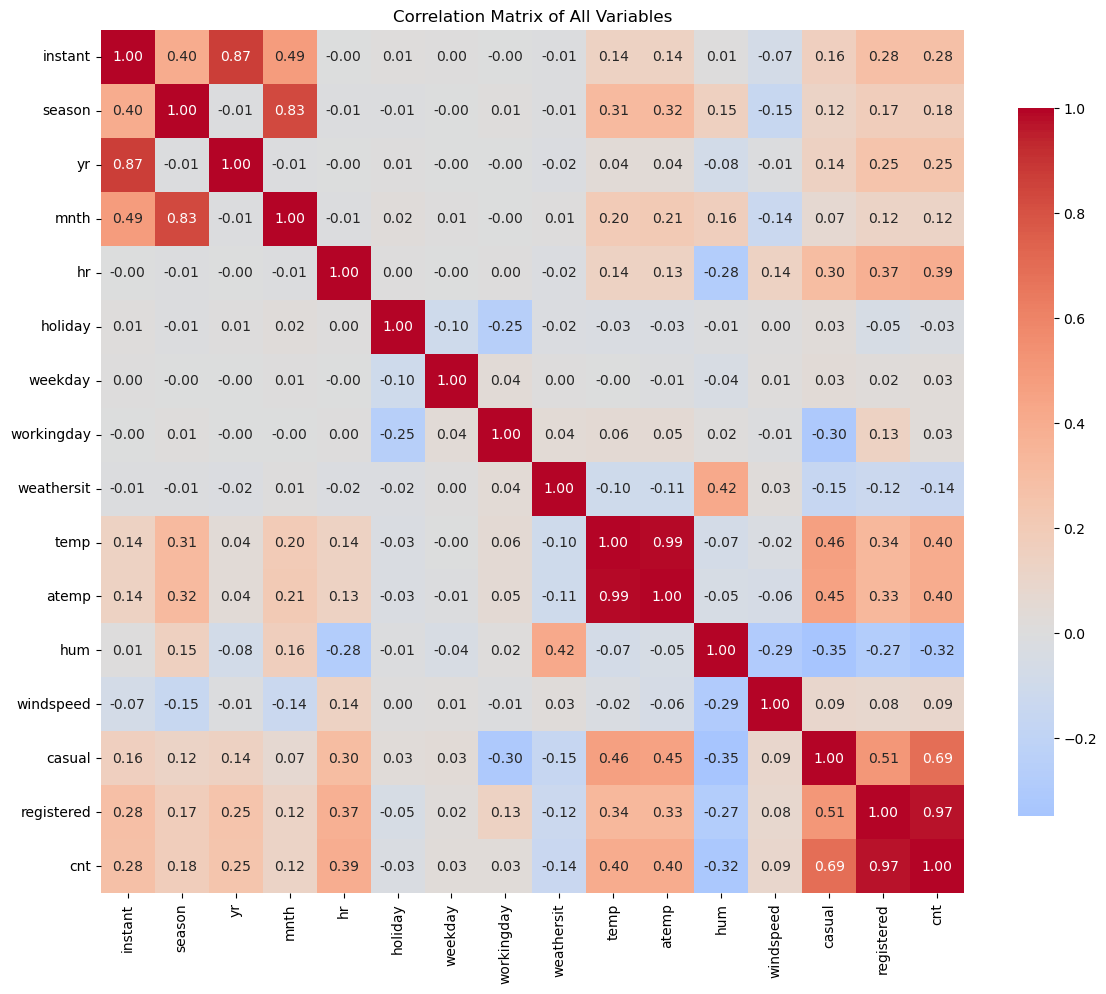

registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
instant       0.278379
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64

In [ ]:
# Your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix over all numeric columns in the raw dataframe
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of All Variables')
plt.tight_layout()
plt.show()

# Correlation of each variable with the target, sorted
corr['cnt'].drop('cnt').sort_values(ascending=False)


In [ ]:
leak_cols = [c for c in ['instant', 'dteday', 'casual', 'registered'] if c in X_train.columns]
X_train = X_train.drop(columns=leak_cols)
X_test = X_test.drop(columns=leak_cols)

categorical_cols = [c for c in ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
                     if c in X_train.columns]

numerical_cols = [c for c in ['temp', 'atemp', 'hum', 'windspeed'] if c in X_train.columns]

X_train_enc = pd.get_dummies(X_train, columns=categorical_cols)
X_test_enc = pd.get_dummies(X_test, columns=categorical_cols)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_enc[numerical_cols] = scaler.fit_transform(X_train_enc[numerical_cols])
X_test_enc[numerical_cols] = scaler.transform(X_test_enc[numerical_cols])

print(f"Training features shape: {X_train_enc.shape}")
print(f"Test features shape:     {X_test_enc.shape}")
X_train_enc.head()


Training features shape: (13903, 61)
Test features shape:     (3476, 61)


,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,...,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
335,-1.540837,-1.620311,-0.399449,0.278669,True,False,False,False,True,False,...,False,False,False,True,True,False,True,False,False,False
7035,0.117112,0.138228,-1.073743,-0.697714,False,False,False,True,True,False,...,False,False,False,False,False,True,True,False,False,False
8051,-0.193753,-0.125843,1.934646,0.278669,False,False,False,True,True,False,...,True,False,False,False,False,True,False,False,True,False
2133,-0.193753,-0.125843,-1.644299,-1.552252,False,True,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False
8485,-1.540837,-1.444457,0.637926,-0.697714,True,False,False,False,True,False,...,False,False,False,False,True,False,True,False,False,False


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [ ]:
# Your code here
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

param_dist = {
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': [100, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10)
}

xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_enc, y_train)

best_params = random_search.best_params_
print("Best parameters found:")
print(best_params)
print(f"Best CV MSE: {-random_search.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:
{'colsample_bytree': 0.6063865008880857, 'learning_rate': 0.0792681476866447, 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 500, 'subsample': 0.8}
Best CV MSE: 1918.506


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [ ]:
# Your code here
# ---- Train the XGBoost and Linear Regression models ----
from sklearn.linear_model import LinearRegression

# XGBoost, using the best hyperparameters found above
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_params,
)
xgb_model.fit(X_train_enc, y_train)

# Linear Regression baseline
lr_model = LinearRegression()
lr_model.fit(X_train_enc, y_train)

print("Both models trained.")


Both models trained.


## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [ ]:
# Your code here
# ---- Make predictions & evaluate ----
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_xgb = xgb_model.predict(X_test_enc)
y_pred_lr = lr_model.predict(X_test_enc)

results = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression'],
    'MSE': [
        mean_squared_error(y_test, y_pred_xgb),
        mean_squared_error(y_test, y_pred_lr),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    ],
    'R2': [
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lr),
    ],
})

results


,Model,MSE,RMSE,R2
0,XGBoost,1666.558907,40.823509,0.947370
1,Linear Regression,10089.388115,100.445946,0.681375


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

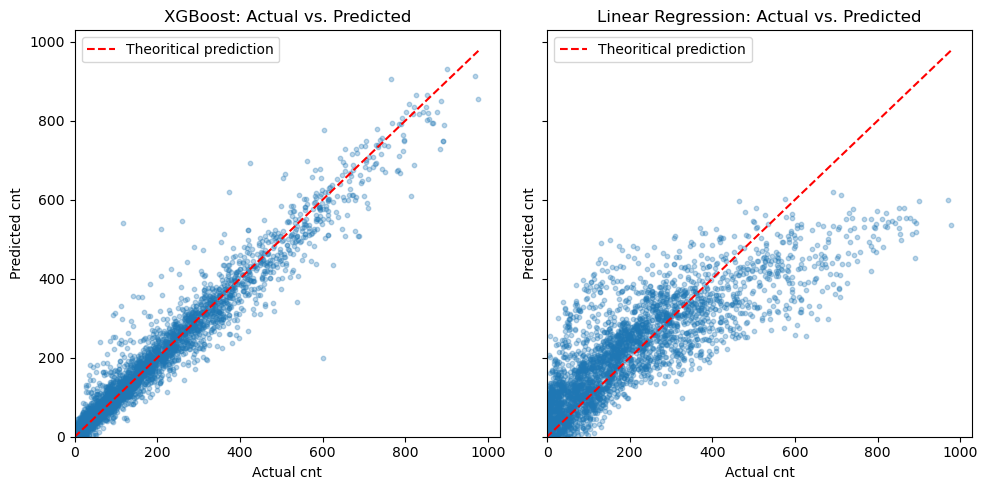

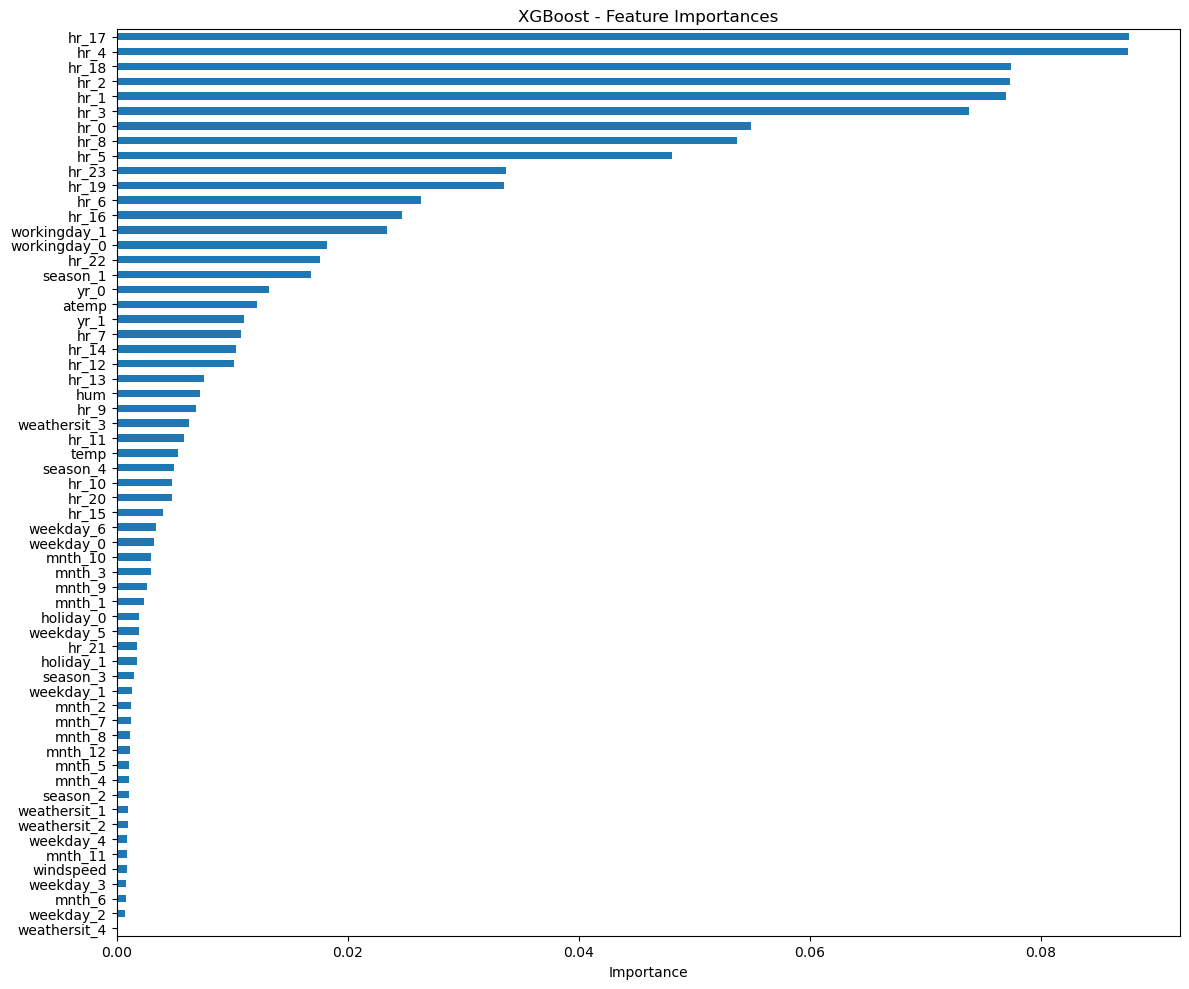

In [ ]:
# Your Code here
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for ax, y_pred, name in zip(axes, [y_pred_xgb, y_pred_lr], ['XGBoost', 'Linear Regression']):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Theoritical prediction')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Actual cnt')
    ax.set_ylabel('Predicted cnt')
    ax.set_title(f'{name}: Actual vs. Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

# Feature importance for XGBoost
importances = pd.Series(xgb_model.feature_importances_, index=X_train_enc.columns)
importances.sort_values(ascending=False).plot(kind='barh', figsize=(12, 10))
plt.gca().invert_yaxis()
plt.title('XGBoost - Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
